In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [2]:
import sys
sys.path.append('..')

from utils.experiment import (
    SimulationConfig,
    OptimizationResult,
    load_experiments,
    load_experiment,
)

In [3]:
from utils.experiment import load_experiments

exp_types = ["cholesky", "block_bootstrapped", "block_bootstrapped_1950"]

data = dict()

for exp_type in exp_types:
    experiments = load_experiments("Results", return_sampler=exp_type)

    if not experiments:
        continue

    init_wealths = np.zeros(len(experiments))
    policies = np.zeros((len(experiments), 3))
    bankruptcy_densities = np.zeros(len(experiments))
    bankruptcy_rates = np.zeros((len(experiments), experiments[0]['config'].SIMULATION_YEARS))

    for i, exp in enumerate(experiments):
        policy = np.ones(3)
        policy[1:3] = exp['result'].best_policy
        policy[0] = 1 - sum(policy[1:3])
        policies[i, :] = policy

        bankruptcy_densities[i] = np.sum(exp['result'].wealth_simulated == 0) / (exp['config'].N_SIMULATIONS * exp['config'].SIMULATION_YEARS)
        bankruptcy_rates[i, :] = np.sum(exp['result'].wealth_simulated[:, 1:] == 0, axis=0) / exp['config'].N_SIMULATIONS

        init_wealths[i] = exp['config'].INITIAL_WEALTH

    data[exp_type] = dict(init_wealths=init_wealths, policies=policies, bankruptcy_densities=bankruptcy_densities, bankruptcy_rates=bankruptcy_rates)


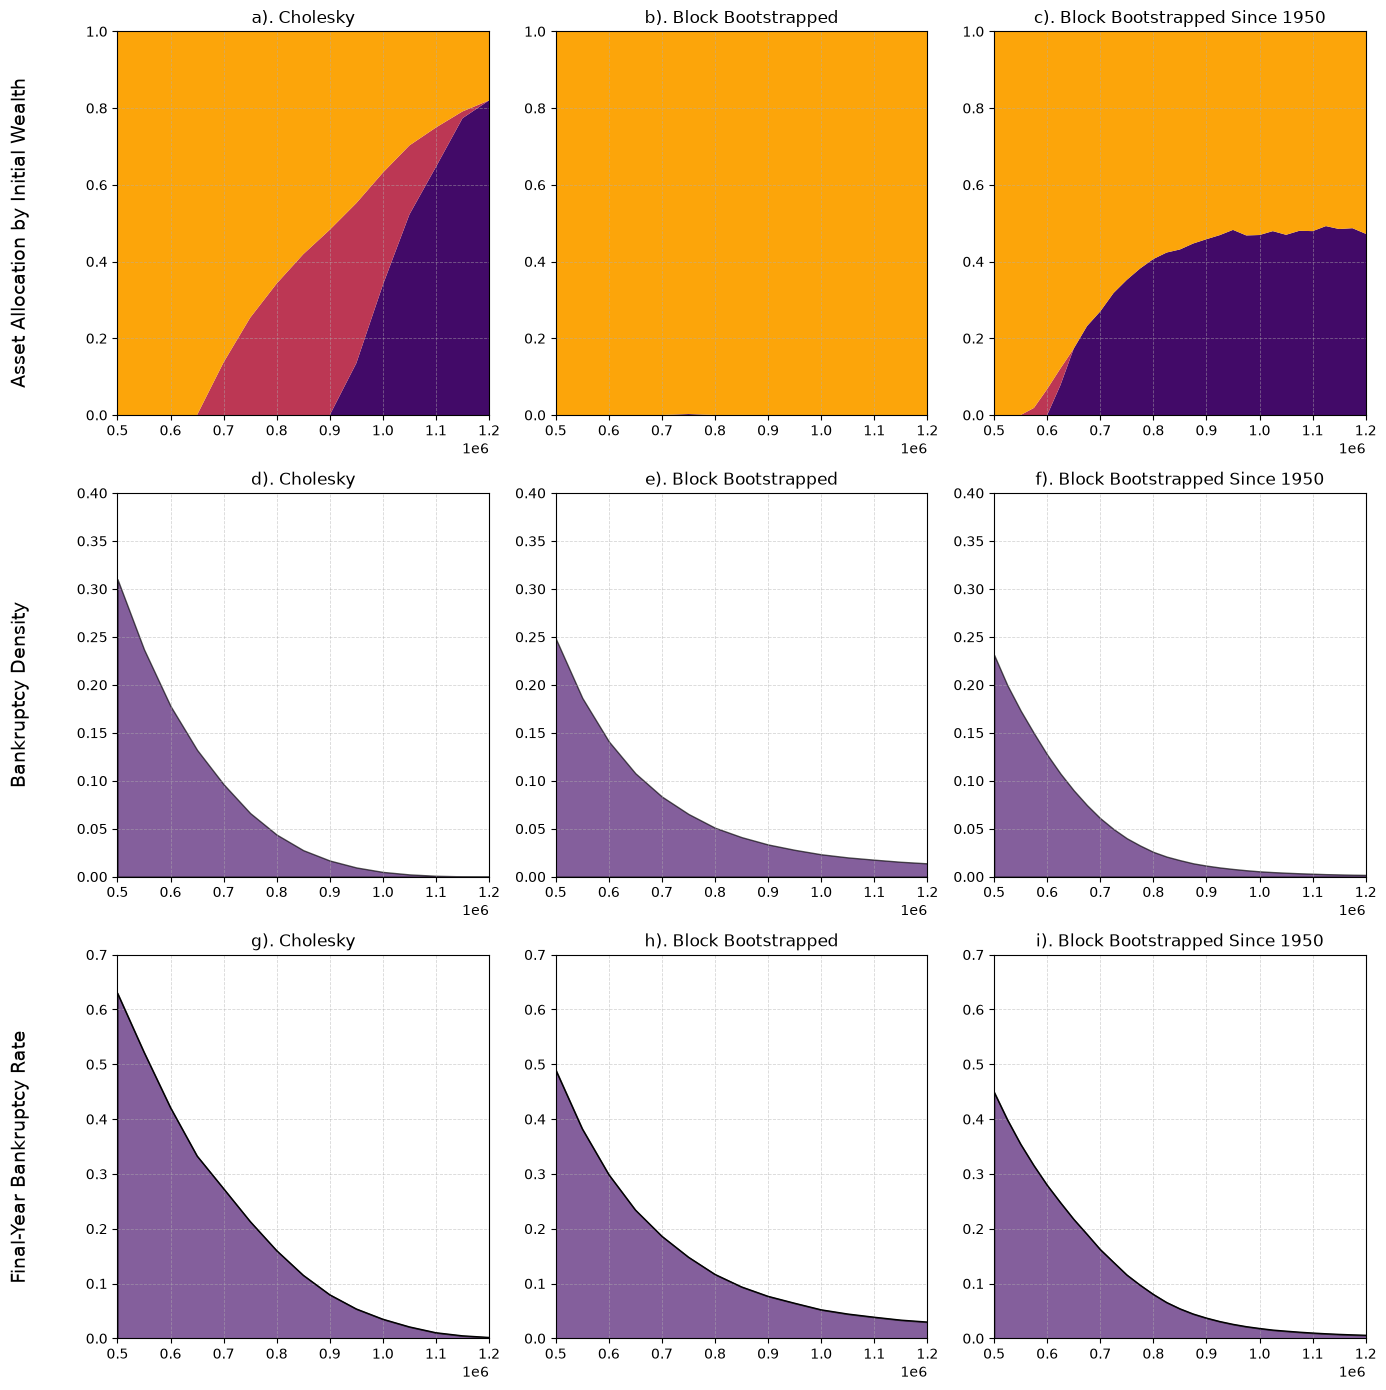

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
import matplotlib.cm as cm

cmap = cm.inferno

allocation_colours = {
    "Cash": cmap(0.2),
    "Bonds": cmap(0.50),
    "Stocks": cmap(0.8),
}

x_min, x_max = 500_000, 1_200_000

for exp_type, this_data in data.items():
    init_wealths = this_data['init_wealths']
    policies = this_data['policies']
    ax_i = exp_types.index(exp_type)
    axes[0, ax_i].stackplot(
        init_wealths,
        *[policies[:, i] for i in range(policies.shape[1])],
        labels=["Bills", "Bonds", "Stocks"],
        colors=allocation_colours.values(),
    )
    axes[0, ax_i].set_xlim(x_min, x_max)
    axes[0, ax_i].set_ylim(0, 1)
    axes[0, ax_i].set_title(f"{chr(ord('a') + ax_i)}). {exp_type.replace('block_bootstrapped', 'block bootstrapped').replace('_', ' since ').title()}")

for exp_type, this_data in data.items():
    init_wealths = this_data['init_wealths']
    bankrupcy_density = this_data['bankruptcy_densities']
    ax_i = exp_types.index(exp_type)
    axes[1, ax_i].fill_between(
        init_wealths,
        bankrupcy_density,
        color=cmap(0.2),
        alpha=0.65,
        linewidth=1.0,
        edgecolor='black',
    )
    axes[1, ax_i].set_xlim(x_min, x_max)
    axes[1, ax_i].set_ylim(0, 0.4)
    axes[1, ax_i].set_title(f"{chr(ord('a') + len(exp_types) + ax_i)}). {exp_type.replace('block_bootstrapped', 'block bootstrapped').replace('_', ' since ').title()}")

for exp_type, this_data in data.items():
    init_wealths = this_data['init_wealths']
    bankrupcy_rates = this_data['bankruptcy_rates']
    final_bankruptcy_rate = bankrupcy_rates[:, -1]
    ax_i = exp_types.index(exp_type)
    axes[2, ax_i].fill_between(
        init_wealths,
        final_bankruptcy_rate,
        color=cmap(0.2),
        alpha=0.65,
        linewidth=1.0,
        edgecolor='black',
    )
    axes[2, ax_i].plot(init_wealths, final_bankruptcy_rate, color='black', linewidth=1.0)
    axes[2, ax_i].set_xlim(x_min, x_max)
    axes[2, ax_i].set_ylim(0, 0.7)
    axes[2, ax_i].set_title(f"{chr(ord('a') + 2 * len(exp_types) + ax_i)}). {exp_type.replace('block_bootstrapped', 'block bootstrapped').replace('_', ' since ').title()}")

# Apply consistent gridlines across all panels.
for ax in axes.ravel():
    ax.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.5)

# Vertical row labels describing each row's metric.
row_label_size = 14
fig.text(0.02, 0.83, 'Asset Allocation by Initial Wealth', va='center', ha='center', rotation=90, fontsize=row_label_size)
fig.text(0.02, 0.50, 'Bankruptcy Density', va='center', ha='center', rotation=90, fontsize=row_label_size)
fig.text(0.02, 0.17, 'Final-Year Bankruptcy Rate', va='center', ha='center', rotation=90, fontsize=row_label_size)

fig.tight_layout(rect=[0.05, 0.0, 1.0, 1.0])
plt.show()

In [5]:
bankrupcy_rates.shape[1]

35

In [6]:
init_wealths

array([ 500000.,  525000.,  550000.,  575000.,  600000.,  625000.,
        650000.,  675000.,  700000.,  725000.,  750000.,  775000.,
        800000.,  825000.,  850000.,  875000.,  900000.,  925000.,
        950000.,  975000., 1000000., 1025000., 1050000., 1075000.,
       1100000., 1125000., 1150000., 1175000., 1200000., 1225000.])

## Experiment Statistics and LaTeX Table

In [7]:
import pandas as pd
from utils.experiment import load_experiments
from utils.metrics import compute_experiment_metrics, pool_experiment_metrics


def _pct(x):
    return f"{100 * x:.2f}\\%"


def _money(x):
    return f"\\${x:,.0f}"


# Per-experiment statistics table
all_experiments = load_experiments("Results")
experiment_stats = pd.DataFrame([
    compute_experiment_metrics(p["config"], p["result"])
    for p in all_experiments
]).sort_values(["sampler", "initial_wealth"]).reset_index(drop=True)

display(experiment_stats.head(30))

# Pooled statistics by sampler
exp_types = ["cholesky", "block_bootstrapped", "block_bootstrapped_1950"]
sampler_rows = []
for sampler in exp_types:
    sampler_experiments = load_experiments("Results", return_sampler=sampler)
    if not sampler_experiments:
        continue
    row = {"sampler": sampler}
    row.update(pool_experiment_metrics(sampler_experiments))
    sampler_rows.append(row)

sampler_summary = pd.DataFrame(sampler_rows).reset_index(drop=True)
display(sampler_summary)

# LaTeX table
latex_table_df = sampler_summary[[
    "sampler", "n_terminal_obs",
    "bankruptcy_rate_terminal", "bankruptcy_rate_ever", "bankruptcy_density",
    "terminal_mean", "terminal_median", "terminal_p05", "terminal_p25", "terminal_p75", "terminal_p95",
    "real_consumption_mean", "real_consumption_median",
    "real_consumption_p05", "real_consumption_p25", "real_consumption_p75", "real_consumption_p95",
]].copy()

latex_table_df["n_terminal_obs"] = latex_table_df["n_terminal_obs"].map(lambda x: f"{x:,}")
for c in ["bankruptcy_rate_terminal", "bankruptcy_rate_ever", "bankruptcy_density"]:
    latex_table_df[c] = latex_table_df[c].map(_pct)
for c in [
    "terminal_mean", "terminal_median", "terminal_p05", "terminal_p25", "terminal_p75", "terminal_p95",
    "real_consumption_mean", "real_consumption_median",
    "real_consumption_p05", "real_consumption_p25", "real_consumption_p75", "real_consumption_p95",
]:
    latex_table_df[c] = latex_table_df[c].map(_money)

latex_table_df = latex_table_df.rename(columns={
    "sampler": "Return sampler",
    "n_terminal_obs": "Terminal obs.",
    "bankruptcy_rate_terminal": "Terminal bankruptcy",
    "bankruptcy_rate_ever": "Ever-bankrupt",
    "bankruptcy_density": "Bankruptcy density",
    "terminal_mean": "Mean terminal wealth",
    "terminal_median": "Median terminal wealth",
    "terminal_p05": "P5 terminal wealth",
    "terminal_p25": "P25 terminal wealth",
    "terminal_p75": "P75 terminal wealth",
    "terminal_p95": "P95 terminal wealth",
    "real_consumption_mean": "Mean real cons.",
    "real_consumption_median": "Median real cons.",
    "real_consumption_p05": "P5 real cons.",
    "real_consumption_p25": "P25 real cons.",
    "real_consumption_p75": "P75 real cons.",
    "real_consumption_p95": "P95 real cons.",
})

latex_table = latex_table_df.to_latex(
    index=False,
    escape=False,
    caption="Key fixed-policy experiment statistics pooled by return sampler.",
    label="tab:fixed_policy_key_stats",
    bold_rows=False,
)

print(latex_table)


,sampler,initial_wealth,n_simulations,years,bankruptcy_rate_terminal,bankruptcy_rate_ever,bankruptcy_density,terminal_mean,terminal_median,terminal_p05,...,consumption_p05,consumption_p25,consumption_p75,consumption_p95,real_consumption_mean,real_consumption_median,real_consumption_p05,real_consumption_p25,real_consumption_p75,real_consumption_p95
0,block_bootstrapped,500000.0,400000,35,0.489805,0.489805,0.248212,2.061166e+06,2.644099e-12,0.000000e+00,...,61013.632241,87123.115611,149189.933233,599548.537828,64453.794630,61820.498185,46055.000000,46055.000000,78780.655891,90748.0
1,block_bootstrapped,550000.0,400000,35,0.382117,0.382117,0.186318,3.376610e+06,3.475599e+05,0.000000e+00,...,62956.780831,88369.430623,152866.761368,617986.189473,65496.089107,63082.141005,46055.000000,54737.733560,78780.655891,90748.0
2,block_bootstrapped,600000.0,400000,35,0.298613,0.298613,0.140965,4.848014e+06,9.930153e+05,0.000000e+00,...,63989.135040,88938.695990,155585.343006,635416.842716,66240.821630,64369.531637,46055.000000,55880.833978,78780.655891,90748.0
3,block_bootstrapped,650000.0,400000,35,0.234118,0.234118,0.107762,6.292624e+06,1.687251e+06,0.000000e+00,...,64615.150234,89405.160398,158027.875001,647961.614056,66771.875624,64369.531637,46055.000000,56254.494941,78780.655891,90748.0
4,block_bootstrapped,700000.0,400000,35,0.186142,0.186142,0.083465,7.895719e+06,2.379967e+06,0.000000e+00,...,65083.988131,89681.883116,159721.845226,653233.995858,67153.596170,65683.195548,46055.000000,56528.989217,78780.655891,90748.0
5,block_bootstrapped,750000.0,400000,35,0.148047,0.148047,0.065351,1.010373e+07,3.127450e+06,0.000000e+00,...,65332.507187,89812.778615,160828.683381,669144.475285,67430.599843,65683.195548,46055.000000,56715.823945,78780.655891,90748.0
6,block_bootstrapped,800000.0,400000,35,0.116598,0.116598,0.051003,1.189962e+07,3.907116e+06,0.000000e+00,...,65344.976542,89843.456508,161883.196960,675313.887856,67642.132922,65683.195548,46055.000000,56929.212363,78780.655891,90748.0
7,block_bootstrapped,850000.0,400000,35,0.093775,0.093775,0.041202,1.436461e+07,4.705960e+06,0.000000e+00,...,65583.569846,89990.498908,162534.648497,677874.084788,67788.368913,65683.195548,48624.218750,57021.259161,78780.655891,90748.0
8,block_bootstrapped,900000.0,400000,35,0.076592,0.076592,0.033554,1.659147e+07,5.494981e+06,0.000000e+00,...,65627.283080,90049.577658,162762.016551,684120.597202,67904.474798,65683.195548,51283.160083,57021.259161,78780.655891,90748.0
9,block_bootstrapped,950000.0,400000,35,0.064010,0.064010,0.027989,1.839564e+07,6.304786e+06,0.000000e+00,...,65523.374950,90036.398828,163520.653265,695767.910736,67983.914588,65683.195548,52086.423503,57021.259161,78780.655891,90748.0


,sampler,n_terminal_obs,bankruptcy_rate_terminal,bankruptcy_rate_ever,bankruptcy_density,terminal_mean,terminal_median,terminal_p05,terminal_p25,terminal_p75,...,consumption_p05,consumption_p25,consumption_p75,consumption_p95,real_consumption_mean,real_consumption_median,real_consumption_p05,real_consumption_p25,real_consumption_p75,real_consumption_p95
0,cholesky,7500000,0.191469,0.191469,0.075097,7.648128e+05,4.753150e+05,0.0,3.317100e+04,9.400719e+05,...,88653.942537,95705.199680,108742.765767,127836.915154,67210.534460,65683.195548,46055.0,56139.309094,78780.655891,90748.0
1,block_bootstrapped,6000000,0.152505,0.152505,0.071758,1.500019e+07,4.205866e+06,0.0,9.122029e+05,1.099859e+07,...,64806.640347,89580.434783,160174.985275,673088.455567,67300.894729,65683.195548,46055.0,56613.412375,78780.655891,90748.0
2,block_bootstrapped_1950,12000000,0.114111,0.114111,0.049371,5.601234e+06,3.630673e+06,0.0,1.335494e+06,7.306754e+06,...,87265.838907,97690.952561,172099.971486,359552.781833,67501.286344,65683.195548,46055.0,56316.608384,78780.655891,90748.0


\begin{table}
\caption{Key fixed-policy experiment statistics pooled by return sampler.}
\label{tab:fixed_policy_key_stats}
\begin{tabular}{lllllllllllllllll}
\toprule
Return sampler & Terminal obs. & Terminal bankruptcy & Ever-bankrupt & Bankruptcy density & Mean terminal wealth & Median terminal wealth & P5 terminal wealth & P25 terminal wealth & P75 terminal wealth & P95 terminal wealth & Mean real cons. & Median real cons. & P5 real cons. & P25 real cons. & P75 real cons. & P95 real cons. \\
\midrule
cholesky & 7,500,000 & 19.15\% & 19.15\% & 7.51\% & \$764,813 & \$475,315 & \$0 & \$33,171 & \$940,072 & \$2,636,572 & \$67,211 & \$65,683 & \$46,055 & \$56,139 & \$78,781 & \$90,748 \\
block_bootstrapped & 6,000,000 & 15.25\% & 15.25\% & 7.18\% & \$15,000,194 & \$4,205,866 & \$0 & \$912,203 & \$10,998,594 & \$41,698,855 & \$67,301 & \$65,683 & \$46,055 & \$56,613 & \$78,781 & \$90,748 \\
block_bootstrapped_1950 & 12,000,000 & 11.41\% & 11.41\% & 4.94\% & \$5,601,234 & \$3,630,673 & \$